# Examen 1 - Predicción de precios de casas con CNN
**Diplomado en Ciencia de Datos - Módulo 4**

La idea es usar las 4 fotos de cada casa (baño, recámara, cocina y fachada)
para predecir su precio. Como no podemos usar múltiples entradas en Sequential,
voy a juntar las 4 imágenes en una sola (grid 2x2) y entrenar una CNN de regresión.

Usé log1p en el precio porque la distribución está muy sesgada y así el modelo
aprende mejor. También normalicé con z-score para que los gradientes sean estables.


## 1. Librerías

In [3]:
import re
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

#from google.colab import drive

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, BatchNormalization, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# semilla para reproducibilidad
semilla = 42
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Rutas del proyecto

In [4]:
carpeta_base     = Path("../data/examen")
carpeta_train    = carpeta_base / "train"
carpeta_validate = carpeta_base / "validate"
ruta_metadata    = carpeta_base / "metadata.txt"

print("carpeta train:   ", carpeta_train.resolve())
print("carpeta validate:", carpeta_validate.resolve())
print("metadata:        ", ruta_metadata.resolve())


carpeta train:    C:\code\diplomado_cdd\moduloIV\data\examen\train
carpeta validate: C:\code\diplomado_cdd\moduloIV\data\examen\validate
metadata:         C:\code\diplomado_cdd\moduloIV\data\examen\metadata.txt


## 3. Cargar metadatos

Solo uso `img` y `price` como dice el examen.

In [5]:
# carga del archivo y uso de columnas permitidas
datos = pd.read_csv(ruta_metadata, sep="|")
datos = datos[["img", "price"]].copy()
datos["img"]   = datos["img"].astype(str)
datos["price"] = datos["price"].astype(float)

print(f"total de casas: {len(datos)}")
print(f"precio minimo:  ${datos['price'].min():,.0f}")
print(f"precio promedio: ${datos['price'].mean():,.0f}")
print(f"precio maximo:  ${datos['price'].max():,.0f}")

datos.head()


total de casas: 535
precio minimo:  $36,000
precio promedio: $627,706
precio maximo:  $5,322,000


,img,price
0,1613,540000.0
1,1656,425000.0
2,1580,245000.0
3,1721,825000.0
4,1581,117000.0


## 4. Exploración rápida del precio

Visualización de la distribución precio antes de modelar.

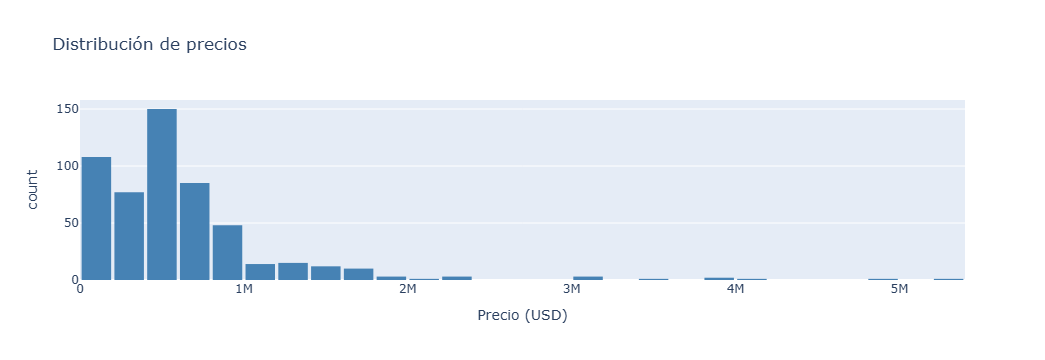

el precio tiene mucho sesgo, se usará log1p para normalizarlo


In [6]:
# histograma de precios
fig = px.histogram(
    datos,
    x="price",
    nbins=40,
    title="Distribución de precios",
    labels={"price": "Precio (USD)", "count": "Cantidad de casas"},
    color_discrete_sequence=["steelblue"]
)
fig.update_layout(bargap=0.1)
fig.show()

# la distribución está sesgada a la derecha, por eso se usa log1p más adelante
print("el precio tiene mucho sesgo, se usará log1p para normalizarlo")


## 5. Funciones para cargar imágenes

Cada casa tiene 4 fotos. Se unen en una imagen de 128x128
(grid 2x2: baño arriba-izq, recámara arriba-der, cocina abajo-izq, fachada abajo-der).


In [7]:
tipos_imagen  = ["bathroom", "bedroom", "kitchen", "frontal"]
tamano_imagen = (64, 64)        # tamaño de cada foto individual
alto_compuesto = tamano_imagen[1] * 2   # 128
ancho_compuesto = tamano_imagen[0] * 2  # 128


def buscar_imagen(carpeta, id_casa, tipo):
    """busca la imagen con distintas extensiones posibles"""
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        ruta = carpeta / f"{id_casa}_{tipo}{ext}"
        if ruta.exists():
            return ruta
    return None


def cargar_y_redimensionar(ruta, tamano=tamano_imagen):
    img = cv2.imread(str(ruta))
    if img is None:
        raise ValueError(f"no se pudo leer: {ruta}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, tamano, interpolation=cv2.INTER_AREA)


def construir_imagen_compuesta(carpeta, id_casa, tamano=tamano_imagen):
    """armado del grid 2x2 con las 4 fotos de la casa"""
    imagenes = []
    for tipo in tipos_imagen:
        ruta = buscar_imagen(carpeta, id_casa, tipo)
        if ruta is None:
            raise FileNotFoundError(f"falta {id_casa}_{tipo}")
        imagenes.append(cargar_y_redimensionar(ruta, tamano=tamano))

    fila_arriba = np.hstack([imagenes[0], imagenes[1]])
    fila_abajo  = np.hstack([imagenes[2], imagenes[3]])
    return np.vstack([fila_arriba, fila_abajo])


def obtener_ids_carpeta(carpeta):
    ids = set()
    patron = re.compile(
        r"^(.*?)_(bathroom|bedroom|kitchen|frontal)\.(jpg|jpeg|png|webp)$",
        re.IGNORECASE)
    for archivo in carpeta.iterdir():
        m = patron.match(archivo.name)
        if m:
            ids.add(m.group(1))
    return sorted(ids)


def cargar_dataset_entrenamiento(carpeta, df, tamano=tamano_imagen):
    imagenes, precios, ids_usados, faltantes = [], [], [], []
    for _, fila in df.iterrows():
        id_casa = str(fila["img"])
        try:
            img = construir_imagen_compuesta(carpeta, id_casa, tamano=tamano)
            imagenes.append(img)
            precios.append(float(fila["price"]))
            ids_usados.append(id_casa)
        except Exception:
            faltantes.append(id_casa)
    return (
        np.array(imagenes, dtype=np.float32),
        np.array(precios, dtype=np.float32),
        ids_usados,
        faltantes
    )


def cargar_dataset_validacion(carpeta, tamano=tamano_imagen):
    imagenes, ids_usados, faltantes = [], [], []
    for id_casa in obtener_ids_carpeta(carpeta):
        try:
            img = construir_imagen_compuesta(carpeta, id_casa, tamano=tamano)
            imagenes.append(img)
            ids_usados.append(id_casa)
        except Exception:
            faltantes.append(id_casa)
    return np.array(imagenes, dtype=np.float32), ids_usados, faltantes


## 6. Cargar y preparar el dataset

In [8]:
X, y, ids_cargados, ids_faltantes = cargar_dataset_entrenamiento(carpeta_train, datos)

print(f"imagenes cargadas: {len(ids_cargados)}")
print(f"casas sin imagenes: {len(ids_faltantes)}")
print(f"shape de X: {X.shape}")

# normalizado los pixeles a [0, 1]
X = X / 255.0

# transformación del precio con log1p para reducir el sesgo
# se aplica z-score para que el modelo aprenda mejor
log_precios  = np.log1p(y)
media_log    = float(log_precios.mean())
std_log      = float(log_precios.std())
y_normalizado = (log_precios - media_log) / std_log

print(f"\nmedia log precio: {media_log:.4f}")
print(f"std log precio:   {std_log:.4f}")
print(f"rango normalizado: [{y_normalizado.min():.2f}, {y_normalizado.max():.2f}]")


imagenes cargadas: 522
casas sin imagenes: 13
shape de X: (522, 128, 128, 3)

media log precio: 12.9665
std log precio:   0.8447
rango normalizado: [-2.93, 2.65]


## 7. Dividir en train y validación

In [9]:
X_entrenamiento, X_validacion, y_entrenamiento, y_validacion, ids_train, ids_val = train_test_split(
    X, y_normalizado, ids_cargados,
    test_size=0.20,
    random_state=semilla
)

print(f"entrenamiento: {X_entrenamiento.shape}")
print(f"validacion:    {X_validacion.shape}")


entrenamiento: (417, 128, 128, 3)
validacion:    (105, 128, 128, 3)


## 8. Data Augmentation

Se usa flip horizontal porque es la única transformación que no
distorsiona las features de precio de una casa.
Rotation y zoom cambian la percepción del tamaño del espacio.


In [10]:
# se incrementa el dataset haciendo un flip horizontal
X_flip = X_entrenamiento[:, :, ::-1, :]
y_flip = y_entrenamiento.copy()

X_aumentado = np.concatenate([X_entrenamiento, X_flip], axis=0)
y_aumentado = np.concatenate([y_entrenamiento, y_flip], axis=0)

# reordenamiento randomizado
rng  = np.random.default_rng(seed=semilla)
perm = rng.permutation(len(X_aumentado))
X_aumentado = X_aumentado[perm]
y_aumentado = y_aumentado[perm]

print(f"train original:  {len(X_entrenamiento)} imagenes")
print(f"train con flip:  {len(X_aumentado)} imagenes")


train original:  417 imagenes
train con flip:  834 imagenes


## 9. Modelo CNN

4 bloques convolucionales + capas densas con regularización L2.
La imagen de entrada es 128x128x3 (el grid 2x2 de las 4 fotos).


In [11]:
forma_entrada = (alto_compuesto, ancho_compuesto, 3)

modelo = Sequential([
    # bloque 1
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=forma_entrada),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # bloque 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # bloque 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # bloque 4
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    # capas densas con L2 para regularizar
    Dense(256, activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(128, activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.20),

    # salida lineal para regresión
    Dense(1, activation="linear")
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

modelo.summary()


C:\code\diplomado_cdd\env\env_mod4\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,374,209 (9.06 MB)

 Trainable params: 2,372,737 (9.05 MB)

 Non-trainable params: 1,472 (5.75 KB)

## 10. Callbacks

In [12]:
ruta_mejor_modelo = "mejor_modelo_casas.keras"

mis_callbacks = [
    EarlyStopping(
        monitor="val_mae",
        mode="min",
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_mae",
        mode="min",
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=ruta_mejor_modelo,
        monitor="val_mae",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
]


## 11. Entrenamiento

In [13]:
%%time
historial = modelo.fit(
    X_aumentado, y_aumentado,
    validation_data=(X_validacion, y_validacion),
    epochs=120,
    batch_size=16,
    callbacks=mis_callbacks,
    shuffle=True,
    verbose=1
)


Epoch 1/120
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 1.0303 - mae: 1.3811
Epoch 1: val_mae improved from None to 1.23452, saving model to mejor_modelo_casas.keras

Epoch 1: finished saving model to mejor_modelo_casas.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 242ms/step - loss: 0.8950 - mae: 1.2326 - val_loss: 0.8579 - val_mae: 1.2345 - learning_rate: 0.0010
Epoch 2/120
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.7112 - mae: 1.0272
Epoch 2: val_mae improved from 1.23452 to 0.88400, saving model to mejor_modelo_casas.keras

Epoch 2: finished saving model to mejor_modelo_casas.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - loss: 0.6655 - mae: 0.9819 - val_loss: 0.5413 - val_mae: 0.8840 - learning_rate: 0.0010
Epoch 3/120
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.5794 - mae: 0.8799
Epoch 3: val_mae improved from 0.88400 to 0.71620, saving model to mejor_modelo_casas.keras

Epoch 3: finished saving model to mejor_modelo_casas.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/

## 12. Curvas de entrenamiento

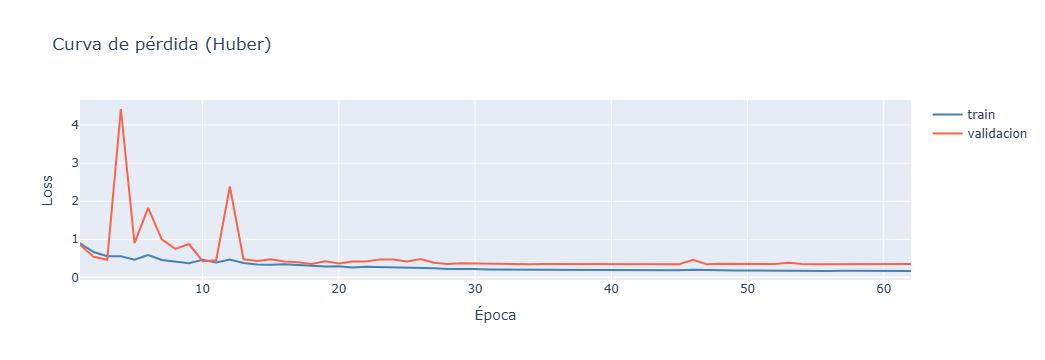

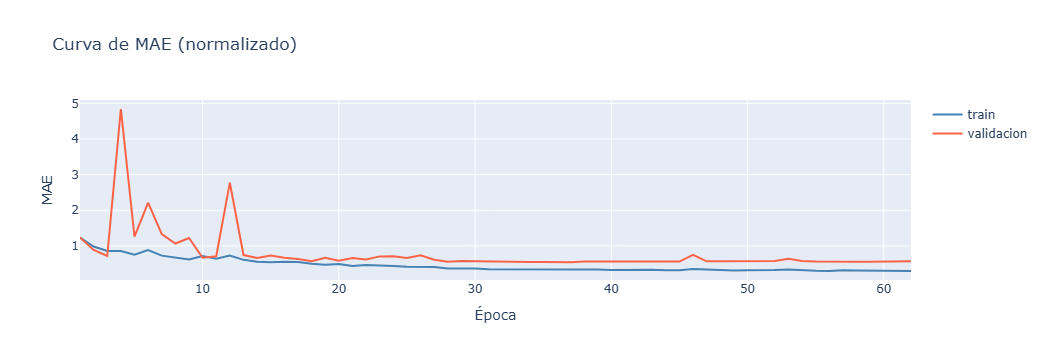

mejor epoca: 37
mejor val_mae: 0.5414


In [14]:
df_historial = pd.DataFrame(historial.history)
epocas = list(range(1, len(df_historial) + 1))

# curva de loss
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(x=epocas, y=df_historial["loss"],
                               mode="lines", name="train",
                               line=dict(color="steelblue")))
fig_loss.add_trace(go.Scatter(x=epocas, y=df_historial["val_loss"],
                               mode="lines", name="validacion",
                               line=dict(color="tomato")))
fig_loss.update_layout(title="Curva de pérdida (Huber)",
                        xaxis_title="Época",
                        yaxis_title="Loss")
fig_loss.show()

# curva de mae
fig_mae = go.Figure()
fig_mae.add_trace(go.Scatter(x=epocas, y=df_historial["mae"],
                              mode="lines", name="train",
                              line=dict(color="steelblue")))
fig_mae.add_trace(go.Scatter(x=epocas, y=df_historial["val_mae"],
                              mode="lines", name="validacion",
                              line=dict(color="tomato")))
fig_mae.update_layout(title="Curva de MAE (normalizado)",
                       xaxis_title="Época",
                       yaxis_title="MAE")
fig_mae.show()

mejor_epoca = df_historial["val_mae"].idxmin() + 1
print(f"mejor epoca: {mejor_epoca}")
print(f"mejor val_mae: {df_historial['val_mae'].min():.4f}")


## 13. Evaluación en validación

MAE en validacion: $206,676.58
error mediano:     $128,070.94


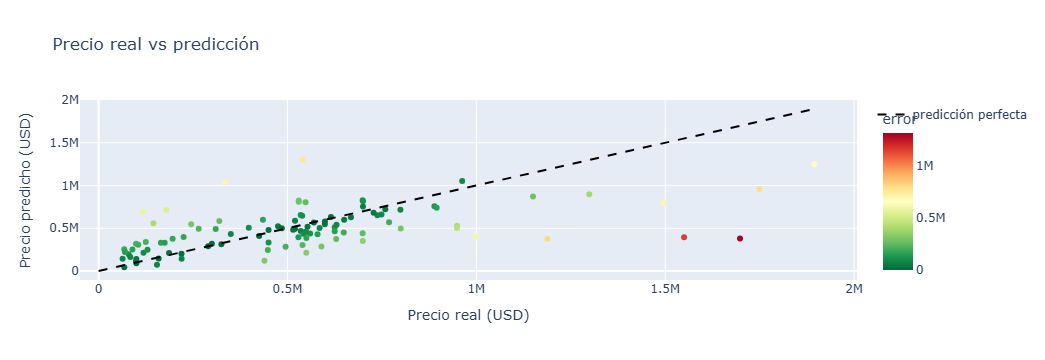

In [15]:
def revertir_normalizacion(y_norm):
    """regresa de z-score + log1p a precio en USD"""
    return np.expm1(y_norm * std_log + media_log)


predicciones_norm = modelo.predict(X_validacion, verbose=0).reshape(-1)
predicciones_usd  = revertir_normalizacion(predicciones_norm)
reales_usd        = revertir_normalizacion(y_validacion)

mae = mean_absolute_error(reales_usd, predicciones_usd)
print(f"MAE en validacion: ${mae:,.2f}")
print(f"error mediano:     ${np.median(np.abs(reales_usd - predicciones_usd)):,.2f}")

# scatter de reales vs predichos
df_resultados = pd.DataFrame({
    "real"       : reales_usd,
    "prediccion" : predicciones_usd,
    "error"      : np.abs(reales_usd - predicciones_usd)
})

fig_scatter = px.scatter(
    df_resultados,
    x="real",
    y="prediccion",
    color="error",
    color_continuous_scale="RdYlGn_r",
    title="Precio real vs predicción",
    labels={"real": "Precio real (USD)", "prediccion": "Precio predicho (USD)"},
)
# línea ideal
max_val = max(reales_usd.max(), predicciones_usd.max())
fig_scatter.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode="lines",
    name="predicción perfecta",
    line=dict(color="black", dash="dash")
))
fig_scatter.show()


## 14. Predicciones sobre el conjunto validate

In [16]:
X_test, ids_test, faltantes_test = cargar_dataset_validacion(carpeta_validate)
X_test = X_test / 255.0

print(f"casas en validate: {len(ids_test)}")

pred_norm_test = modelo.predict(X_test, verbose=0).reshape(-1)
pred_usd_test  = revertir_normalizacion(pred_norm_test)

df_predicciones = pd.DataFrame({
    "img"       : ids_test,
    "price_pred": np.round(pred_usd_test, 2)
}).sort_values("img")

print(f"precio minimo predicho:  ${df_predicciones['price_pred'].min():,.0f}")
print(f"precio promedio predicho: ${df_predicciones['price_pred'].mean():,.0f}")
print(f"precio maximo predicho:  ${df_predicciones['price_pred'].max():,.0f}")

df_predicciones


casas en validate: 13
precio minimo predicho:  $104,560
precio promedio predicho: $430,412
precio maximo predicho:  $897,934


,img,price_pred
0,1583,450579.250000
1,1603,620030.375000
2,1608,437451.625000
3,1707,476236.625000
4,1742,202145.765625
5,1771,384606.156250
6,1848,136429.328125
7,1859,897934.312500
8,1904,541991.125000
9,1989,104559.570312


In [17]:
df_predicciones.to_csv("predicciones_validate.csv", index=False)
print("archivo guardado: predicciones_validate.csv")


archivo guardado: predicciones_validate.csv


## 15. Visualización de predicciones

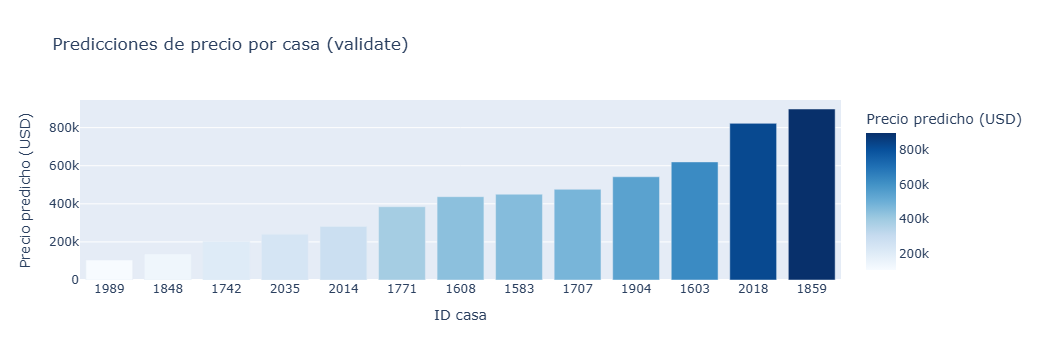

In [18]:
# gráfica de barras con las predicciones de validate
fig_bar = px.bar(
    df_predicciones.sort_values("price_pred"),
    x="img",
    y="price_pred",
    title="Predicciones de precio por casa (validate)",
    labels={"img": "ID casa", "price_pred": "Precio predicho (USD)"},
    color="price_pred",
    color_continuous_scale="Blues"
)
fig_bar.show()
